# Helpfulness Analysis
Examine what drives helpful votes across ratings, sentiment, length, and reviewer experience.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

In [2]:
# Load dataset
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)

Loaded: Processed_Reviews.csv
Shape: (16156, 41)


In [3]:
# Validate required columns
required_cols = ["Helpful_Votes", "Rating", "Review_Length", "Reviewer_Experience"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

In [4]:
# Overall helpfulness distribution
print("\n=== Helpful Votes Distribution ===")
print(df["Helpful_Votes"].describe())

print("\n=== Helpful Bucket Distribution ===")
if "Helpful_Bucket" in df.columns:
    print(df["Helpful_Bucket"].value_counts())


=== Helpful Votes Distribution ===
count    16156.000000
mean         0.709458
std          3.672513
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        233.000000
Name: Helpful_Votes, dtype: float64

=== Helpful Bucket Distribution ===
Helpful_Bucket
Low       5641
Medium     140
High        17
Name: count, dtype: int64


In [5]:
# Helpfulness vs rating
helpful_by_rating = df.groupby("Rating")["Helpful_Votes"].mean()
print("\n=== Avg Helpful Votes by Rating ===")
print(helpful_by_rating)


=== Avg Helpful Votes by Rating ===
Rating
1    2.326489
2    0.992401
3    0.580794
4    0.570824
5    0.712773
Name: Helpful_Votes, dtype: float64


In [6]:
# Helpfulness vs sentiment
if "Combined_Sentiment" in df.columns:
    helpful_by_sentiment = df.groupby("Combined_Sentiment")["Helpful_Votes"].mean()
    print("\n=== Avg Helpful Votes by Sentiment ===")
    print(helpful_by_sentiment)
else:
    helpful_by_sentiment = None


=== Avg Helpful Votes by Sentiment ===
Combined_Sentiment
NEGATIVE    1.186150
NEUTRAL     0.748075
POSITIVE    0.645174
Name: Helpful_Votes, dtype: float64


In [7]:
# Helpfulness vs review length
if "Length_Bucket" in df.columns:
    helpful_by_length = df.groupby("Length_Bucket")["Helpful_Votes"].mean()
    print("\n=== Avg Helpful Votes by Length Bucket ===")
    print(helpful_by_length)
else:
    helpful_by_length = None


=== Avg Helpful Votes by Length Bucket ===
Length_Bucket
Long          0.891755
Medium        0.599490
Short         0.446986
Very Short    0.000000
Name: Helpful_Votes, dtype: float64


In [8]:
# Helpfulness vs reviewer experience
helpful_by_experience = df.groupby("Reviewer_Experience")["Helpful_Votes"].mean()
print("\n=== Avg Helpful Votes by Reviewer Experience ===")
print(helpful_by_experience)


=== Avg Helpful Votes by Reviewer Experience ===
Reviewer_Experience
Active    0.809051
Casual    0.682993
Expert    0.548387
New       0.759396
Name: Helpful_Votes, dtype: float64


In [9]:
# Helpfulness ratio analysis
if "Helpfulness_Ratio" in df.columns:
    print("\n=== Helpfulness Ratio Summary ===")
    print(df["Helpfulness_Ratio"].describe())
    ratio_by_rating = df.groupby("Rating")["Helpfulness_Ratio"].mean()
    print("\n=== Avg Helpfulness Ratio by Rating ===")
    print(ratio_by_rating)
else:
    ratio_by_rating = None


=== Helpfulness Ratio Summary ===
count    16156.000000
mean         0.036533
std          0.356890
min          0.000000
25%          0.000000
50%          0.000000
75%          0.012346
max         23.250000
Name: Helpfulness_Ratio, dtype: float64

=== Avg Helpfulness Ratio by Rating ===
Rating
1    0.234380
2    0.054954
3    0.020186
4    0.024104
5    0.035425
Name: Helpfulness_Ratio, dtype: float64


In [10]:
# Top helpful reviews
top_helpful_reviews = df.sort_values(by="Helpful_Votes", ascending=False).head(20)
print("\n=== Top 20 Most Helpful Reviews ===")
print(top_helpful_reviews[["Location_Name", "Rating", "Helpful_Votes", "Review_Length"]])


=== Top 20 Most Helpful Reviews ===
                              Location_Name  Rating  Helpful_Votes  \
6291                             Galle Fort       5            233   
15597                  Dambulla Cave Temple       5            182   
9880                Minneriya National Park       5            180   
7015                            Polonnaruwa       5            166   
7619     Sigiriya The Ancient Rock Fortress       4             93   
6719                          Liptons Seat       5             90   
7614     Sigiriya The Ancient Rock Fortress       5             82   
1455                    Mount Lavinia Beach       5             71   
11460                Udawattekele Sanctuary       4             63   
1653                          Negombo Beach       5             62   
14813  Gangaramaya (Vihara) Buddhist Temple       5             62   
2460                             Kandy Lake       4             53   
462                         Hikkaduwa Beach       4  

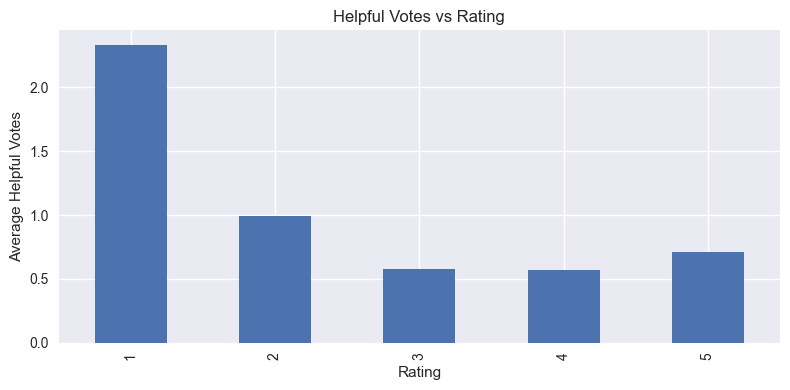

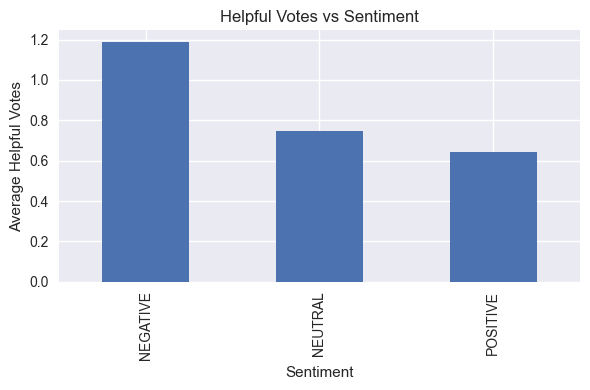

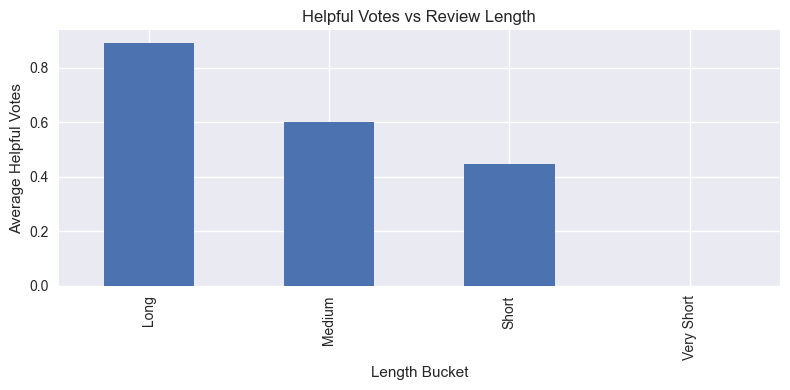

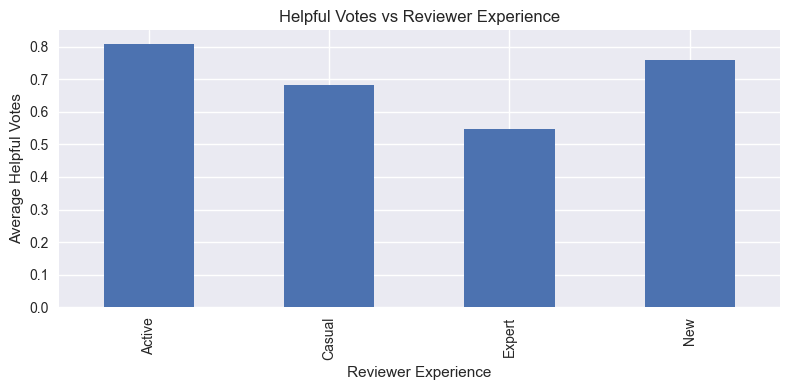

In [11]:
# Plots
plt.figure(figsize=(8, 4))
helpful_by_rating.plot(kind="bar")
plt.title("Helpful Votes vs Rating")
plt.xlabel("Rating")
plt.ylabel("Average Helpful Votes")
plt.tight_layout()
plt.show()

if helpful_by_sentiment is not None:
    plt.figure(figsize=(6, 4))
    helpful_by_sentiment.plot(kind="bar")
    plt.title("Helpful Votes vs Sentiment")
    plt.xlabel("Sentiment")
    plt.ylabel("Average Helpful Votes")
    plt.tight_layout()
    plt.show()

if helpful_by_length is not None:
    plt.figure(figsize=(8, 4))
    helpful_by_length.plot(kind="bar")
    plt.title("Helpful Votes vs Review Length")
    plt.xlabel("Length Bucket")
    plt.ylabel("Average Helpful Votes")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
helpful_by_experience.plot(kind="bar")
plt.title("Helpful Votes vs Reviewer Experience")
plt.xlabel("Reviewer Experience")
plt.ylabel("Average Helpful Votes")
plt.tight_layout()
plt.show()

In [12]:
# Save outputs
helpful_by_rating.to_csv("helpful_by_rating.csv")
helpful_by_experience.to_csv("helpful_by_experience.csv")

if helpful_by_sentiment is not None:
    helpful_by_sentiment.to_csv("helpful_by_sentiment.csv")

if helpful_by_length is not None:
    helpful_by_length.to_csv("helpful_by_length.csv")

if ratio_by_rating is not None:
    ratio_by_rating.to_csv("helpfulness_ratio_by_rating.csv")

top_helpful_reviews.to_csv("top_helpful_reviews.csv", index=False)

print("\n✅ Helpfulness analysis complete.")
print("Saved files:")
print("- helpful_by_rating.csv")
print("- helpful_by_experience.csv")
print("- helpful_by_sentiment.csv")
print("- helpful_by_length.csv")
print("- helpfulness_ratio_by_rating.csv")
print("- top_helpful_reviews.csv")


✅ Helpfulness analysis complete.
Saved files:
- helpful_by_rating.csv
- helpful_by_experience.csv
- helpful_by_sentiment.csv
- helpful_by_length.csv
- helpfulness_ratio_by_rating.csv
- top_helpful_reviews.csv
